# Stochastic Optimization of Control Policies via Neuroevolution

We optimize an 8→64→4 neural policy for the discrete-action LunarLander-v3 environment without gradients. Actions are 0: no-op, 1: left orientation engine, 2: main engine, 3: right orientation engine.

All episodes use a 500-step horizon. Phase 1 evaluates every candidate on the same training seed; later phases use the same three additional training seeds. Development seeds (20,000–20,099) are reused to compare phases. Only the final controller is evaluated on test seeds 30,000–30,099. Seeds improve repeatability within a fixed software environment; one training run does not measure variation across independent training runs.


In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import numpy as np
import random
import copy
from torch.nn.utils import parameters_to_vector, vector_to_parameters

SEED = 1337
POPULATION_SIZE = 100 
GENERATIONS = 100
MAX_STEPS = 500
TRAIN_SEEDS = (SEED + 100, SEED + 101, SEED + 102)
DEV_SEED_START = 20_000
TEST_SEED_START = 30_000
torch.set_num_threads(1) 
MUTATION_POWER = 0.02 
DEVICE = torch.device("cpu")  # Tested on CPU; exact results depend on runtime versions.

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    
    # CRITICAL: Force PyTorch operations to be deterministic
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    # Environment seeds are supplied explicitly at each reset.

import os
set_seed(SEED)

env = gym.make("LunarLander-v3", max_episode_steps=MAX_STEPS)

print(f"Environment: {env.spec.id}")
print(f"Observation Space: {env.observation_space.shape[0]} dim")
print(f"Action Space: {env.action_space.n} discrete actions")
print(f"Compute Device: {DEVICE}")

Environment: LunarLander-v3
Observation Space: 8 dim
Action Space: 4 discrete actions
Compute Device: cpu


## 2. The Parametric Model ($\pi_\theta$) & Genotype-Phenotype Mapping

We define the policy $\pi_\theta(a|s)$ as a Multilayer Perceptron (MLP).

**Architecture:**
*   Input Layer: 8 neurons (State state)
*   Hidden Layer: 64 neurons (Activation: Hyperbolic Tangent $\tanh$)
*   Output Layer: 4 neurons (logits for Softmax/Argmax)

**The Isomorphism:**
To perform evolution, we map the network parameters $\mathcal{W}$ (a set of weight matrices and bias vectors) to a flat genotype vector $\theta$:

$$ f: \mathcal{W} \rightarrow \mathbb{R}^N $$

Where $N$ is the total number of parameters.
*   **Genotype:** Flat vector $\theta$ (manipulated by evolution).
*   **Phenotype:** The structured Neural Network (interacts with environment).

We implement `get_genotype` and `set_genotype` to handle this mapping efficiently using PyTorch's `parameters_to_vector` and `vector_to_parameters`.

In [2]:
class NeuroController(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # Standard MLP topology
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, output_size)
        )
        # Disable gradient computation for efficiency
        for p in self.net.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.net(x)

    def get_genotype(self):
        """Flatten all parameters into a single 1D tensor."""
        return parameters_to_vector(self.net.parameters())

    def set_genotype(self, theta):
        """Inflate a 1D tensor back into the network architecture."""
        vector_to_parameters(theta, self.net.parameters())

    def mutate(self, power=0.02):
        """Apply additive Gaussian noise: theta' = theta + N(0, sigma)."""
        theta = self.get_genotype()
        noise = torch.randn_like(theta) * power
        self.set_genotype(theta + noise)

# Inspection
hidden_dim = 64
agent = NeuroController(env.observation_space.shape[0], hidden_dim, env.action_space.n)
param_count = agent.get_genotype().numel()

print(f"Network Topology: 8 -> {hidden_dim} -> 4")
print(f"Dimensionality of Genotype Space (R^N): {param_count}")
print(f"Sample Genotype Head (First 10 genes): {agent.get_genotype()[:10].numpy()}")

Network Topology: 8 -> 64 -> 4
Dimensionality of Genotype Space (R^N): 836
Sample Genotype Head (First 10 genes): [-0.29817483 -0.00309944  0.08704352 -0.05484451 -0.21185741 -0.3332922
  0.06019139  0.13907085 -0.22900431 -0.17004053]


## 3. Population Initialization and Fitness

We stack PyTorch Linear layers' default initializations into a population tensor. Fitness is cumulative environment reward over at most 500 steps, without clipping negative returns. It includes shaping, landing/crash terms and fuel penalties; it is not a direct landing-success label.


In [3]:
POPULATION_SIZE = 100
MAX_STEPS = 500

def get_random_genotype(base_agent, index): 
    """
    Generates a random genotype using the architecture's default init (Kaiming/Xavier) 
    by enforcing a local seed for each index.
    """
    # Preserve the caller's RNG state while initializing this individual.
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(SEED + index)
        for layer in base_agent.net:
            if isinstance(layer, nn.Linear):
                layer.reset_parameters()

    return base_agent.get_genotype()

def init_population(pop_size, base_agent):
    """Creates a tensor of shape (pop_size, gene_count)."""
    gene_count = base_agent.get_genotype().numel()
    pop_tensor = torch.zeros(pop_size, gene_count)
    
    for i in range(pop_size):
        pop_tensor[i] = get_random_genotype(base_agent, i)
        
    return pop_tensor

def evaluate(agent, genotype, env, render=False, seed=SEED):
    """
    Injects genotype into agent, runs one episode, returns Cumulative Reward.
    """
    agent.set_genotype(genotype)
    obs, _ = env.reset(seed=seed)
    total_reward = 0
    
    for step in range(MAX_STEPS):
        if render:
            env.render()
            
        # 1. Forward pass (No Grad)
        obs_tensor = torch.from_numpy(obs).float()
        with torch.no_grad():
            logits = agent(obs_tensor)
        
        # 2. Action selection (Argmax)
        action = torch.argmax(logits).item()
        
        # 3. Physics step
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        
        if terminated or truncated:
            break
            
    return total_reward

# Initialize the Primordial Soup
population = init_population(POPULATION_SIZE, agent)

print(f"Population Tensor P: {population.shape}")
print(f"Mean Gene Value: {population.mean():.4f}")
print(f"Gene Variance: {population.var():.4f}")

# Benchmark one run
print("\nBenchmarking a random agent...")
import time
start = time.time()
score = evaluate(agent, population[0], env)
end = time.time()
print(f"Random Agent Score: {score:.2f}")
print(f"Episode Evaluation Time: {(end-start)*1000:.2f} ms")

Population Tensor P: torch.Size([100, 836])
Mean Gene Value: 0.0008
Gene Variance: 0.0304

Benchmarking a random agent...
Random Agent Score: -480.30
Episode Evaluation Time: 2.67 ms


## 4. Genetic Operators: Selection, Recombination, and Mutation

To drive the optimization, we implement the standard evolutionary cycle.

**1. Elitism:**
The best solution $\theta^*$ of generation $t$ is copied directly to $t+1$. This preserves fitness only when candidates are evaluated on the same deterministic objective.

**2. Tournament Selection:**
To select a parent, we sample $k$ individuals uniformly at random and choose the one with the highest fitness.
Tournament selection favours higher-scoring candidates; its probabilities depend on tournament size and tied ranks.
This avoids scaling issues with raw reward values (negative vs positive).

**3. Uniform Crossover:**
Given two parents $\theta_A$ and $\theta_B$, we construct a child $\theta_C$:
$$ \theta_C[j] = \begin{cases} \theta_A[j] & \text{if } r < 0.5 \\ \theta_B[j] & \text{otherwise} \end{cases} $$
This allows the mixing of individual parameters (whose effects can be interdependent).

**4. Gaussian Mutation:**
$$ \theta' = \theta + \mathcal{N}(0, \sigma^2 I) $$
Exploration mechanism to search the neighborhood of the current solution.

In [4]:
def tournament_selection(population, fitness_scores, k=3):
    """
    Selects one parent index using Tournament Selection.
    k: Selection pressure (higher k = greedier selection).
    """
    pop_size = len(fitness_scores)
    indices = torch.randint(0, pop_size, (k,))
    candidates_scores = fitness_scores[indices]
    best_idx_in_subset = torch.argmax(candidates_scores)
    return indices[best_idx_in_subset]

def crossover(parent_a, parent_b):
    """Performs uniform crossover (50/50 mix of genes)."""
    mask = torch.rand_like(parent_a) > 0.5
    child = torch.where(mask, parent_a, parent_b)
    return child

def mutate(genotype, mutation_power=0.02):
    """Adds Gaussian noise to the genotype."""
    noise = torch.randn_like(genotype) * mutation_power
    return genotype + noise

def create_next_generation(population, fitness_scores, elitism_count=1):
    pop_size, gene_count = population.shape
    new_population = torch.zeros_like(population)
    
    # 1. Elitism: Copy best performers directly
    sorted_indices = torch.argsort(fitness_scores, descending=True)
    for i in range(elitism_count):
        best_idx = sorted_indices[i]
        new_population[i] = population[best_idx]
        
    # 2. Reproduction loop
    for i in range(elitism_count, pop_size):
        # Select Parents
        idx_a = tournament_selection(population, fitness_scores)
        idx_b = tournament_selection(population, fitness_scores)
        
        # Crossover
        child = crossover(population[idx_a], population[idx_b])
        
        # Mutation
        child = mutate(child)
        
        new_population[i] = child
        
    return new_population

# Unit Test of Operators
mock_scores = torch.tensor([-100.0, 50.0, 200.0, -500.0]) # 3rd agent is best
winner_idx = tournament_selection(None, mock_scores, k=2)
print(f"Tournament Selection Test (Indices): {winner_idx}")

p1 = torch.zeros(10)
p2 = torch.ones(10)
child = crossover(p1, p2)
print(f"Crossover Test (Mix of 0s and 1s): \n{child}")

Tournament Selection Test (Indices): 3
Crossover Test (Mix of 0s and 1s): 
tensor([1., 0., 0., 1., 1., 1., 0., 1., 1., 1.])


## 5. The Optimization Loop (Training)

We execute the evolutionary process over $G$ generations.
**Metric Tracking:**
*   **Max Fitness:** The performance of the current $\theta^*$.
*   **Genetic Diversity:** $\mathcal{D} = \frac{1}{N} \sum_{j=1}^N \sqrt{\text{Var}(\theta_j)}$. A measure of parameter dispersion, not entropy.

We capture snapshots of the population tensor $P_t$ to visualize the optimization trajectory in high-dimensional space later.

In [5]:
import time

set_seed(SEED)
env.reset(seed=SEED)
population = init_population(POPULATION_SIZE, agent)
# -----------------------------------------------
GENERATIONS = 100
PRINT_EVERY = 5

# Metrics storage
history_max = []
history_mean = []
history_diversity = []
population_snapshots = [] # For t-SNE later
snapshot_generations = []

print(f"Starting Evolution: {GENERATIONS} Generations, {POPULATION_SIZE} Agents.")
start_time = time.time()

for gen in range(1, GENERATIONS + 1):
    fitness_scores = []
    
    # 1. Evaluation Step
    # Ideally parallelized, but sequential here for simplicity/compatibility
    for i in range(POPULATION_SIZE):
        score = evaluate(agent, population[i], env)
        fitness_scores.append(score)
        
    fitness_scores = torch.tensor(fitness_scores)
    
    # 2. Logging
    max_score = fitness_scores.max().item()
    mean_score = fitness_scores.mean().item()
    diversity = population.std(dim=0).mean().item()
    
    history_max.append(max_score)
    history_mean.append(mean_score)
    history_diversity.append(diversity)
    
    # Snapshot for visualization (every 5 gens to save RAM)
    if gen == 1 or gen % 5 == 0:
        population_snapshots.append(population.clone())
        snapshot_generations.append(gen)
    
    if gen % PRINT_EVERY == 0 or gen == 1:
        elapsed = time.time() - start_time
        print(f"Gen {gen:02d} | Max: {max_score:7.2f} | Mean: {mean_score:7.2f} | Diversity: {diversity:.4f} | Time: {elapsed:.0f}s")
        
    # 3. Evolution Step (Selection -> Crossover -> Mutation)
    if gen < GENERATIONS:
        population = create_next_generation(population, fitness_scores)

total_time = time.time() - start_time
print(f"\nTraining Complete. Total time: {total_time/60:.2f} minutes.")

# Extract best agent
best_idx = torch.argmax(fitness_scores)
best_genotype = population[best_idx]
print(f"Best Genotype found. Score: {fitness_scores[best_idx]:.2f}")

Starting Evolution: 100 Generations, 100 Agents.


Gen 01 | Max:    0.61 | Mean: -413.52 | Diversity: 0.1631 | Time: 0s


Gen 05 | Max:   39.09 | Mean: -287.33 | Diversity: 0.1610 | Time: 1s


Gen 10 | Max:   39.09 | Mean: -254.71 | Diversity: 0.1572 | Time: 2s


Gen 15 | Max:   53.19 | Mean: -194.94 | Diversity: 0.1509 | Time: 2s


...

Gen 80 | Max:  275.88 | Mean:  -29.21 | Diversity: 0.1215 | Time: 14s


Gen 85 | Max:  275.88 | Mean:  -31.03 | Diversity: 0.1190 | Time: 15s


Gen 90 | Max:  275.88 | Mean:  -26.92 | Diversity: 0.1202 | Time: 16s


Gen 95 | Max:  275.88 | Mean:  -40.25 | Diversity: 0.1199 | Time: 17s


Gen 100 | Max:  277.46 | Mean:  -35.84 | Diversity: 0.1184 | Time: 18s

Training Complete. Total time: 0.29 minutes.
Best Genotype found. Score: 277.46


## 6. Evolutionary Dynamics

The curves below report the current execution's training fitness and mean parameter standard deviation. A high score on one training seed does not establish generalization. The second curve measures parameter dispersion, not information-theoretic entropy.


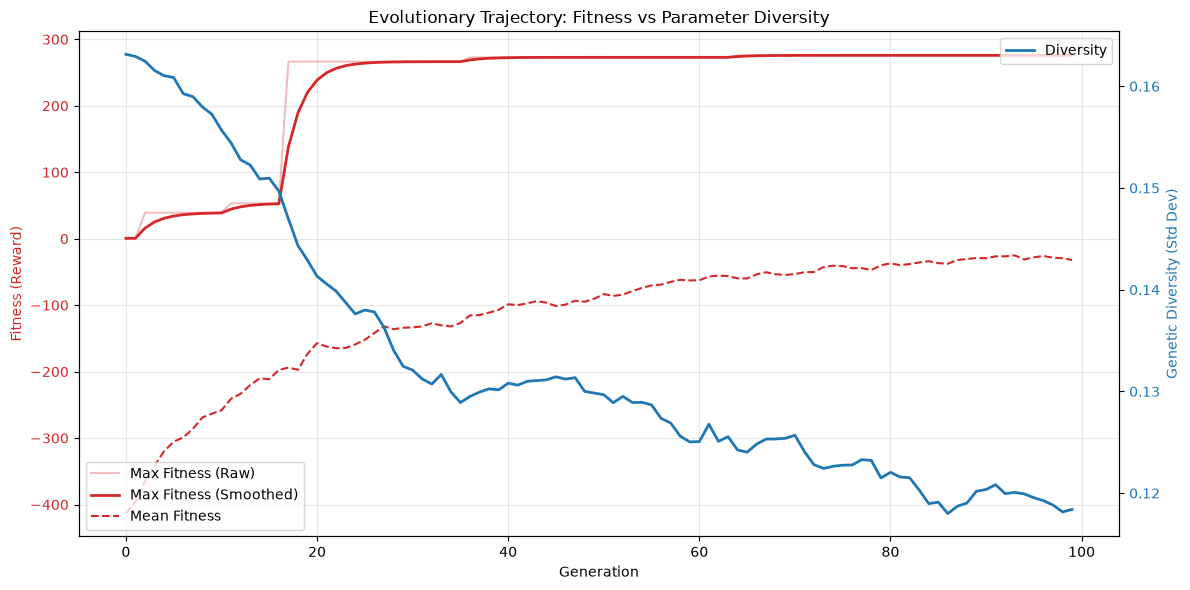

In [6]:
import matplotlib.pyplot as plt

# Smoothing function for cleaner plots
def smooth(scalars, weight=0.6):
    last = scalars[0]
    smoothed = []
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: Fitness
color = 'tab:red'
ax1.set_xlabel('Generation')
ax1.set_ylabel('Fitness (Reward)', color=color)
ax1.plot(history_max, color=color, alpha=0.3, label='Max Fitness (Raw)')
ax1.plot(smooth(history_max), color=color, linewidth=2, label='Max Fitness (Smoothed)')
ax1.plot(smooth(history_mean), color=color, linestyle='--', label='Mean Fitness')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.3)

# Secondary Axis: Diversity
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Genetic Diversity (Std Dev)', color=color)
ax2.plot(history_diversity, color=color, linewidth=2, label='Diversity')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title("Evolutionary Trajectory: Fitness vs Parameter Diversity")
plt.tight_layout()
plt.show()

## 7. t-SNE Visualization

We project snapshots of the 836-parameter population into two dimensions, labelled by their actual generation numbers. t-SNE emphasizes local neighbourhoods; global distances, apparent paths, shapes and cluster sizes do not establish fitness barriers or the topology of the original parameter space.


Projecting 2100 genotypes from $\mathbb{R}^{836}$ to $\mathbb{R}^2$...


/Users/alejandrotreny/Library/Mobile Documents/com~apple~CloudDocs/Github/Data Science/Data-Science-Ecosystem/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:378: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/alejandrotreny/Library/Mobile Documents/com~apple~CloudDocs/Github/Data Science/Data-Science-Ecosystem/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:378: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/alejandrotreny/Library/Mobile Documents/com~apple~CloudDocs/Github/Data Science/Data-Science-Ecosystem/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:378: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/alejandrotreny/Library/Mobile Documents/com~apple~CloudDocs/Github/Data Science/Data-Science-Ecosystem/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:379: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = norma

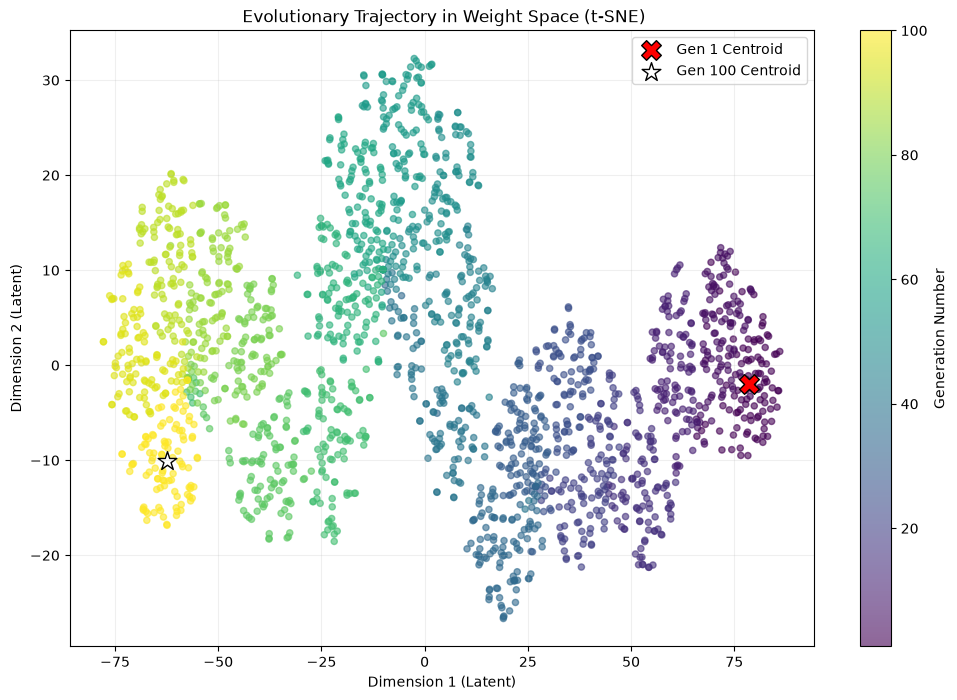

In [7]:
from sklearn.manifold import TSNE
import matplotlib.cm as cm

# 1. Prepare Data
# Stack all snapshots into a single matrix (Total Agents x Genes)
all_gens_data = torch.cat(population_snapshots, dim=0).numpy()
total_snapshots = len(population_snapshots)
agents_per_snap = POPULATION_SIZE

generation_labels = np.repeat(snapshot_generations, agents_per_snap)
assert len(generation_labels) == len(all_gens_data)

print(fr"Projecting {len(all_gens_data)} genotypes from $\mathbb{{R}}^{{{all_gens_data.shape[1]}}}$ to $\mathbb{{R}}^2$...")

# 2. Run t-SNE (The Heavy Lifting)
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
embedding = tsne.fit_transform(all_gens_data)

# 3. Visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embedding[:, 0], 
    embedding[:, 1], 
    c=generation_labels, 
    cmap='viridis', 
    alpha=0.6,
    s=20
)

plt.colorbar(scatter, label='Generation Number')
plt.title(f" Evolutionary Trajectory in Weight Space (t-SNE)")
plt.xlabel("Dimension 1 (Latent)")
plt.ylabel("Dimension 2 (Latent)")
plt.grid(True, alpha=0.2)

# Mark the start and end centroids
start_centroid = embedding[:agents_per_snap].mean(axis=0)
end_centroid = embedding[-agents_per_snap:].mean(axis=0)

plt.scatter(*start_centroid, c='red', s=200, marker='X', edgecolors='black', label='Gen 1 Centroid')
plt.scatter(*end_centroid, c='white', s=200, marker='*', edgecolors='black', label=f'Gen {GENERATIONS} Centroid')
plt.legend()
plt.show()

## 8. Visual Development Episode

We record the Phase 1 winner on a development seed as an inline animation. Its training score came from a different seed. Inspect the actual trajectory; reward thresholds alone do not classify physical landing outcomes.


In [8]:
# Reconstruct and record the Phase 1 agent on a development seed.
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

def show_episode(controller, seed):
    render_env = gym.make("LunarLander-v3", render_mode="rgb_array", max_episode_steps=MAX_STEPS)
    frames = []
    total_reward = 0.0
    try:
        obs, _ = render_env.reset(seed=seed)
        for step in range(MAX_STEPS):
            if step % 5 == 0:
                frames.append(render_env.render())
            with torch.no_grad():
                action = controller(torch.from_numpy(obs).float()).argmax().item()
            obs, reward, terminated, truncated, _ = render_env.step(action)
            total_reward += reward
            if terminated or truncated:
                frames.append(render_env.render())
                break
    finally:
        render_env.close()
    fig, ax = plt.subplots(figsize=(6, 4))
    artist = ax.imshow(frames[0]); ax.axis("off")
    def update(i):
        artist.set_data(frames[i]); return (artist,)
    ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=100, blit=True)
    plt.close(fig)
    display(HTML(ani.to_jshtml()))
    print(f"Development-seed episode reward: {total_reward:.2f}")

winner_agent = NeuroController(env.observation_space.shape[0], hidden_dim, env.action_space.n)
winner_agent.set_genotype(best_genotype.clone())
show_episode(winner_agent, DEV_SEED_START)


Development-seed episode reward: -85.51


## 9. Development Evaluation

Evaluate the selected Phase 1 controller on 100 fixed development seeds. Report mean reward, standard deviation and the fractions above 200 or below -100. These are reward thresholds, not measured landing and crash rates. Development results can inform later phases and are therefore not the final test set.


In [9]:
set_seed(SEED)
def validate_agent(agent, episodes=100, seed_start=DEV_SEED_START):
    rewards = []
    high_returns = 0
    low_returns = 0
    
    print(f"Running Monte Carlo Validation ({episodes} episodes)...")
    
    # We use a separate env to not mess with rendering settings
    val_env = gym.make("LunarLander-v3", max_episode_steps=MAX_STEPS)
    
    for i in range(episodes):
        obs, _ = val_env.reset(seed=seed_start + i)
        total_reward = 0
        terminated = False
        truncated = False
        
        while not (terminated or truncated):
            obs_tensor = torch.from_numpy(obs).float()
            with torch.no_grad():
                logits = agent(obs_tensor)
            action = torch.argmax(logits).item()
            
            obs, reward, terminated, truncated, _ = val_env.step(action)
            total_reward += reward
            
        rewards.append(total_reward)
        
        if total_reward > 200:
            high_returns += 1
            outcome = "✅"
        elif total_reward < -100:
            low_returns += 1
            outcome = "💥"
        else:
            outcome = "⚠️"
            
        print(f"   Run {i+1:02d}: Reward {total_reward:7.2f} | {outcome}")
        
    val_env.close()
    
    return np.array(rewards), high_returns, low_returns

rewards, high_returns, low_returns = validate_agent(winner_agent)

print(f"\nValidation Summary:")
print(f"   Mean Reward: {rewards.mean():.2f} +/- SD {rewards.std():.2f}")
print(f"   Reward > 200 rate: {high_returns}/{len(rewards)} ({(high_returns/len(rewards))*100:.1f}%)")
print(f"   Reward < -100 rate:   {low_returns}/{len(rewards)} ({(low_returns/len(rewards))*100:.1f}%)")

Running Monte Carlo Validation (100 episodes)...
   Run 01: Reward  -85.51 | ⚠️
   Run 02: Reward -336.70 | 💥
   Run 03: Reward -353.93 | 💥
   Run 04: Reward -147.62 | 💥
   Run 05: Reward -333.29 | 💥
   Run 06: Reward  229.17 | ✅
   Run 07: Reward -260.24 | 💥
   Run 08: Reward -315.53 | 💥
   Run 09: Reward -119.69 | 💥
   Run 10: Reward -102.18 | 💥
   Run 11: Reward    2.10 | ⚠️
   Run 12: Reward -103.79 | 💥
   Run 13: Reward -313.29 | 💥
   Run 14: Reward  -24.32 | ⚠️
   Run 15: Reward -250.83 | 💥
   Run 16: Reward -115.27 | 💥
   Run 17: Reward -335.61 | 💥
   Run 18: Reward -270.18 | 💥
   Run 19: Reward -281.37 | 💥
   Run 20: Reward  236.17 | ✅
   Run 21: Reward  -15.23 | ⚠️
   Run 22: Reward -202.18 | 💥
   Run 23: Reward -274.33 | 💥
   Run 24: Reward -298.53 | 💥
   Run 25: Reward -262.89 | 💥
   Run 26: Reward -434.81 | 💥
   Run 27: Reward -166.26 | 💥
   Run 28: Reward -364.94 | 💥
   Run 29: Reward -199.18 | 💥
   Run 30: Reward -221.06 | 💥
   Run 31: Reward  -25.97 | ⚠️
   Run 32: Rewar

   Run 82: Reward  -43.12 | ⚠️
   Run 83: Reward   -6.90 | ⚠️


   Run 84: Reward -334.96 | 💥
   Run 85: Reward -281.82 | 💥
   Run 86: Reward -229.68 | 💥
   Run 87: Reward -316.24 | 💥
   Run 88: Reward -287.38 | 💥
   Run 89: Reward -284.13 | 💥
   Run 90: Reward -309.90 | 💥
   Run 91: Reward  -86.57 | ⚠️
   Run 92: Reward -523.51 | 💥
   Run 93: Reward -296.80 | 💥
   Run 94: Reward  235.96 | ✅
   Run 95: Reward   23.39 | ⚠️
   Run 96: Reward  -84.12 | ⚠️
   Run 97: Reward -215.70 | 💥
   Run 98: Reward -329.83 | 💥
   Run 99: Reward -327.68 | 💥
   Run 100: Reward -320.97 | 💥

Validation Summary:
   Mean Reward: -187.98 +/- SD 174.82
   Reward > 200 rate: 7/100 (7.0%)
   Reward < -100 rate:   72/100 (72.0%)


## 10. Three-Seed Training Objective

Later phases optimize the mean return over three fixed training seeds shared by all candidates. Every candidate runs all three episodes. This removes unequal evaluation conditions within a generation but can still overfit those three seeds.


In [10]:
def evaluate_robust(agent, genotype, env, runs=3):
    """Mean return on the same fixed training seeds for every candidate."""
    if runs < 1 or runs > len(TRAIN_SEEDS):
        raise ValueError("runs must select between one and three training seeds")
    return float(np.mean([evaluate(agent, genotype, env, seed=seed)
                          for seed in TRAIN_SEEDS[:runs]]))

start = time.time()
test_score = evaluate_robust(agent, population[0], env)
print(f"Three-training-seed mean: {test_score:.2f}; evaluation time: {time.time()-start:.2f}s")


Three-training-seed mean: -71.00; evaluation time: 0.01s


## 11. Phase 2: Continue Evolution

Continue the Phase 1 population for 30 generations on the three-seed objective. Mutation standard deviation decreases from 0.05 to 0.01. This is continued optimization; improvement and generalization must be assessed from the outputs below.


In [11]:
GENERATIONS_PHASE_2 = 30
START_MUTATION = 0.05
END_MUTATION = 0.01

set_seed(SEED) 
env.reset(seed=SEED)

history_max_robust = []
history_mean_robust = []

print(f"Starting Robust Evolution (Phase 2): {GENERATIONS_PHASE_2} Gens, 3-Run Average.")
start_time = time.time()

for gen in range(1, GENERATIONS_PHASE_2 + 1):
    fitness_scores = []
    
    # Calculate adaptive mutation rate
    current_sigma = START_MUTATION - ((gen - 1) / (GENERATIONS_PHASE_2 - 1)) * (START_MUTATION - END_MUTATION)
    
    # 1. Robust Evaluation
    for i in range(POPULATION_SIZE):
        score = evaluate_robust(agent, population[i], env, runs=3)
        fitness_scores.append(score)
        
    fitness_scores = torch.tensor(fitness_scores)
    
    # 2. Logging
    max_score = fitness_scores.max().item()
    mean_score = fitness_scores.mean().item()
    history_max_robust.append(max_score)
    history_mean_robust.append(mean_score)
    
    if gen % 2 == 0 or gen == 1:
        elapsed = time.time() - start_time
        print(f"Gen {gen:02d} | Max: {max_score:7.2f} | Mean: {mean_score:7.2f} | Sigma: {current_sigma:.3f} | Time: {elapsed:.0f}s")
        
    # 3. Evolution with Adaptive Mutation
    if gen < GENERATIONS_PHASE_2:
        # We need to pass the current_sigma to the mutation function. 
        # Since our previous 'create_next_generation' hardcoded mutation, we modify logic inline here.
        
        new_population = torch.zeros_like(population)
        
        # Elitism
        sorted_indices = torch.argsort(fitness_scores, descending=True)
        new_population[0] = population[sorted_indices[0]] # Save #1
        new_population[1] = population[sorted_indices[1]] # Save #2
        
        # Reproduction
        for i in range(2, POPULATION_SIZE):
            idx_a = tournament_selection(population, fitness_scores, k=5) # Higher pressure
            idx_b = tournament_selection(population, fitness_scores, k=5)
            
            child = crossover(population[idx_a], population[idx_b])
            child = mutate(child, mutation_power=current_sigma) # Adaptive sigma
            new_population[i] = child
            
        population = new_population

total_time = time.time() - start_time
print(f"\nPhase 2 Complete. Total time: {total_time/60:.2f} minutes.")

best_idx_robust = torch.argmax(fitness_scores)
best_genotype_robust = population[best_idx_robust]
print(f"Robust Best Score (3-run avg): {fitness_scores[best_idx_robust]:.2f}")

Starting Robust Evolution (Phase 2): 30 Gens, 3-Run Average.


Gen 01 | Max:   13.78 | Mean:  -73.21 | Sigma: 0.050 | Time: 1s


Gen 02 | Max:   57.56 | Mean:  -59.17 | Sigma: 0.049 | Time: 1s


Gen 04 | Max:  119.72 | Mean:  -56.35 | Sigma: 0.046 | Time: 3s


Gen 06 | Max:  153.85 | Mean:  -59.19 | Sigma: 0.043 | Time: 5s


...

Gen 22 | Max:  243.05 | Mean:   45.88 | Sigma: 0.021 | Time: 20s


Gen 24 | Max:  243.74 | Mean:   17.85 | Sigma: 0.018 | Time: 23s


Gen 26 | Max:  243.74 | Mean:   39.78 | Sigma: 0.016 | Time: 25s


Gen 28 | Max:  243.95 | Mean:   53.63 | Sigma: 0.013 | Time: 27s


Gen 30 | Max:  249.22 | Mean:   60.69 | Sigma: 0.010 | Time: 29s

Phase 2 Complete. Total time: 0.48 minutes.
Robust Best Score (3-run avg): 249.22


## 12. Phase 2 Development Evaluation

Evaluate the Phase 2 controller on the same 100 development seeds used for Phase 1, using matching episode horizons and denominators. This comparison describes this run and does not isolate the effect of any one algorithmic change.


In [12]:
# Create a new instance of the agent with the robust genotype
robust_agent = NeuroController(env.observation_space.shape[0], hidden_dim, env.action_space.n)
robust_agent.set_genotype(best_genotype_robust)

# Run the validation suite
rewards_robust, high_returns_robust, low_returns_robust = validate_agent(robust_agent, episodes=100)

print(f"\nRobust Validation Summary:")
print(f"   Mean Reward: {rewards_robust.mean():.2f} +/- SD {rewards_robust.std():.2f}")
print(f"   Reward > 200 rate: {high_returns_robust}/{len(rewards_robust)} ({(high_returns_robust/len(rewards_robust))*100:.1f}%)")
print(f"   Reward < -100 rate:   {low_returns_robust}/{len(rewards_robust)} ({(low_returns_robust/len(rewards_robust))*100:.1f}%)")

# Compare rates on the same 100 development seeds using their actual denominators.
print(f"Low-return rate reduction: {(low_returns / len(rewards) - low_returns_robust / len(rewards_robust)) * 100:.1f} percentage points")


Running Monte Carlo Validation (100 episodes)...
   Run 01: Reward -145.80 | 💥
   Run 02: Reward -301.12 | 💥
   Run 03: Reward  -29.76 | ⚠️
   Run 04: Reward  -95.99 | ⚠️
   Run 05: Reward -254.94 | 💥
   Run 06: Reward  233.32 | ✅
   Run 07: Reward -181.10 | 💥
   Run 08: Reward -476.23 | 💥
   Run 09: Reward  -97.22 | ⚠️
   Run 10: Reward  -61.78 | ⚠️
   Run 11: Reward  240.64 | ✅
   Run 12: Reward  -78.15 | ⚠️
   Run 13: Reward   11.63 | ⚠️
   Run 14: Reward  -14.25 | ⚠️
   Run 15: Reward   63.06 | ⚠️
   Run 16: Reward  234.12 | ✅
   Run 17: Reward -208.29 | 💥
   Run 18: Reward -154.53 | 💥
   Run 19: Reward -140.13 | 💥
   Run 20: Reward  244.23 | ✅
   Run 21: Reward  218.10 | ✅
   Run 22: Reward -161.43 | 💥
   Run 23: Reward -142.92 | 💥
   Run 24: Reward -184.62 | 💥
   Run 25: Reward  -22.53 | ⚠️
   Run 26: Reward  -10.76 | ⚠️
   Run 27: Reward  -85.83 | ⚠️
   Run 28: Reward -357.03 | 💥
   Run 29: Reward  -73.44 | ⚠️
   Run 30: Reward   17.47 | ⚠️
   Run 31: Reward  -94.30 | ⚠️
   Run 

   Run 83: Reward   48.68 | ⚠️
   Run 84: Reward -297.60 | 💥
   Run 85: Reward    8.16 | ⚠️
   Run 86: Reward -249.40 | 💥
   Run 87: Reward  -88.37 | ⚠️
   Run 88: Reward  -45.39 | ⚠️
   Run 89: Reward  -32.89 | ⚠️
   Run 90: Reward  179.05 | ⚠️
   Run 91: Reward  -65.00 | ⚠️
   Run 92: Reward   -7.93 | ⚠️
   Run 93: Reward -244.60 | 💥
   Run 94: Reward  257.39 | ✅
   Run 95: Reward   32.16 | ⚠️
   Run 96: Reward  183.89 | ⚠️
   Run 97: Reward  -85.86 | ⚠️
   Run 98: Reward  -50.89 | ⚠️
   Run 99: Reward -308.97 | 💥
   Run 100: Reward -163.34 | 💥

Robust Validation Summary:
   Mean Reward: -87.25 +/- SD 153.63
   Reward > 200 rate: 8/100 (8.0%)
   Reward < -100 rate:   42/100 (42.0%)
Low-return rate reduction: 30.0 percentage points


In [13]:
show_episode(robust_agent, DEV_SEED_START)


Development-seed episode reward: -145.80


## 13. Phase 3: Partial Population Restart

Create 80 new random individuals and retain 20 elite-derived individuals: one unchanged controller and 19 heavily mutated clones (standard deviation 0.5). Then evolve for 20 generations. The preserved controller protects its score on the fixed training objective; it does not guarantee test performance.


In [14]:

RESTART_GENERATIONS = 20
EXPLOSION_MUTATION_POWER = 0.5 
REINIT_PERCENTAGE = 0.8
ELITE_CLONE_COUNT = round(POPULATION_SIZE * (1 - REINIT_PERCENTAGE))
NEW_POP_COUNT = POPULATION_SIZE - ELITE_CLONE_COUNT

set_seed(SEED)
env.reset(seed=SEED)

print(f"Recycling Genes: Keeping {ELITE_CLONE_COUNT} Elites, Generating {NEW_POP_COUNT} New Agents.")

# 1. New Population Initialization (Partial Reset)
population_new_gen = torch.zeros_like(population)

# A) Fill with random genotypes (The Big Bang)
# Usamos un agente temporal para sacar la arquitectura
temp_agent = NeuroController(env.observation_space.shape[0], hidden_dim, env.action_space.n)

for i in range(NEW_POP_COUNT):
    # CORRECCIÓN: Le pasamos 'i' como índice para que la semilla interna varíe correctamente
    population_new_gen[i] = get_random_genotype(temp_agent, i)

# B) Targeted Mutation (Exploding the Elite)
population_new_gen[NEW_POP_COUNT] = best_genotype_robust.clone() 
print("  -> Saved 1 Pure Elite (Safety Anchor).")

# El resto de huecos se llenan con clones mutados
for i in range(1, ELITE_CLONE_COUNT):
    # Clone the best genotype found in Phase 2
    recycled_elite = best_genotype_robust.clone()
    
    # Subject to massive mutation (Forced Search)
    recycled_elite = mutate(recycled_elite, mutation_power=EXPLOSION_MUTATION_POWER)
    
    # Place in the new population
    population_new_gen[NEW_POP_COUNT + i] = recycled_elite

population = population_new_gen
history_max_phase3 = []
history_mean_phase3 = []

START_MUTATION_P3 = 0.1 # Starting higher for a better jump
END_MUTATION_P3 = 0.005

print(f"Starting Recycling Evolution (Phase 3): {RESTART_GENERATIONS} Gens, High Mutation Restart.")
start_time = time.time()

for gen in range(1, RESTART_GENERATIONS + 1):
    fitness_scores = []
    
    # Calculate adaptive mutation rate for Phase 3
    current_sigma = START_MUTATION_P3 - ((gen - 1) / (RESTART_GENERATIONS - 1)) * (START_MUTATION_P3 - END_MUTATION_P3)
    
    # 1. Robust Evaluation (K=3)
    for i in range(POPULATION_SIZE):
        score = evaluate_robust(agent, population[i], env, runs=3)
        fitness_scores.append(score)
        
    fitness_scores = torch.tensor(fitness_scores)
    
    # 2. Logging
    max_score = fitness_scores.max().item()
    mean_score = fitness_scores.mean().item()
    history_max_phase3.append(max_score)
    history_mean_phase3.append(mean_score)
    
    if gen % 2 == 0 or gen == 1:
        elapsed = time.time() - start_time
        print(f"Gen {gen:02d} | Max: {max_score:7.2f} | Mean: {mean_score:7.2f} | Sigma: {current_sigma:.4f} | Time: {elapsed:.0f}s")
        
    # 3. Evolution with Adaptive Mutation
    if gen < RESTART_GENERATIONS:
        new_population = torch.zeros_like(population)
        
        # Elitism
        sorted_indices = torch.argsort(fitness_scores, descending=True)
        new_population[0] = population[sorted_indices[0]] 
        new_population[1] = population[sorted_indices[1]] 
        
        # Reproduction
        for i in range(2, POPULATION_SIZE):
            idx_a = tournament_selection(population, fitness_scores, k=5) 
            idx_b = tournament_selection(population, fitness_scores, k=5)
            
            child = crossover(population[idx_a], population[idx_b])
            child = mutate(child, mutation_power=current_sigma) 
            new_population[i] = child
            
        population = new_population

total_time_phase3 = time.time() - start_time
print(f"\nPhase 3 Complete. Total time: {total_time_phase3/60:.2f} minutes.")

best_idx_p3 = torch.argmax(fitness_scores)
final_best_genotype = population[best_idx_p3]
print(f"Final Best Score (3-run avg): {fitness_scores[best_idx_p3]:.2f}")

Recycling Genes: Keeping 20 Elites, Generating 80 New Agents.
  -> Saved 1 Pure Elite (Safety Anchor).
Starting Recycling Evolution (Phase 3): 20 Gens, High Mutation Restart.


Gen 01 | Max:  249.22 | Mean: -397.41 | Sigma: 0.1000 | Time: 1s


Gen 02 | Max:  249.22 | Mean: -342.33 | Sigma: 0.0950 | Time: 1s


Gen 04 | Max:  249.22 | Mean: -168.48 | Sigma: 0.0850 | Time: 2s


Gen 06 | Max:  249.22 | Mean:  -94.44 | Sigma: 0.0750 | Time: 4s


...

Gen 12 | Max:  249.22 | Mean:   15.20 | Sigma: 0.0450 | Time: 9s


Gen 14 | Max:  249.22 | Mean:   19.02 | Sigma: 0.0350 | Time: 11s


Gen 16 | Max:  249.22 | Mean:   30.47 | Sigma: 0.0250 | Time: 14s


Gen 18 | Max:  249.22 | Mean:   61.46 | Sigma: 0.0150 | Time: 16s


Gen 20 | Max:  249.22 | Mean:   57.77 | Sigma: 0.0050 | Time: 18s

Phase 3 Complete. Total time: 0.30 minutes.
Final Best Score (3-run avg): 249.22


## 14. Phase 4: Local Search

Initialize around the Phase 3 winner and evolve for 15 generations with mutation standard deviation 0.002. Actions remain discrete; small weight changes do not imply proportional changes in engine thrust.


In [15]:
GENERATIONS_PHASE_4 = 15 
ULTRA_LOW_MUTATION = 0.002 

set_seed(SEED)
env.reset(seed=SEED)

print(f"Starting Phase 4: Monoculture Initialization around Score {fitness_scores[best_idx_p3]:.2f}...")

# 1. Monoculture Initialization
population_final = torch.zeros_like(population)

population_final[0] = final_best_genotype.clone() 

for i in range(1, POPULATION_SIZE):
    clone = final_best_genotype.clone()
    population_final[i] = mutate(clone, mutation_power=ULTRA_LOW_MUTATION)

population = population_final
history_max_p4 = []

print(f"Starting Ultra-Fine Tuning (Phase 4): {GENERATIONS_PHASE_4} Gens, Sigma={ULTRA_LOW_MUTATION}")
start_time = time.time()

for gen in range(1, GENERATIONS_PHASE_4 + 1):
    fitness_scores = []
    
    # 1. Robust Evaluation (K=3)
    for i in range(POPULATION_SIZE):
        score = evaluate_robust(agent, population[i], env, runs=3)
        fitness_scores.append(score)
        
    fitness_scores = torch.tensor(fitness_scores)
    
    # 2. Logging
    max_score = fitness_scores.max().item()
    mean_score = fitness_scores.mean().item()
    history_max_p4.append(max_score)
    
    if gen % 2 == 0 or gen == 1:
        elapsed = time.time() - start_time
        print(f"Gen {gen:02d} | Max: {max_score:7.2f} | Mean: {mean_score:7.2f} | Sigma: {ULTRA_LOW_MUTATION:.4f} | Time: {elapsed:.0f}s")
        
    # 3. Evolution (High Pressure, Low Mutation)
    if gen < GENERATIONS_PHASE_4:
        new_population = torch.zeros_like(population)
        
        # Super Elitism (Keep top 5 to prevent drift)
        sorted_indices = torch.argsort(fitness_scores, descending=True)
        for i in range(5):
            new_population[i] = population[sorted_indices[i]]
            
        # Reproduction
        for i in range(5, POPULATION_SIZE):
            # High pressure (k=7) to pick only the very best micro-variants
            idx_a = tournament_selection(population, fitness_scores, k=7) 
            idx_b = tournament_selection(population, fitness_scores, k=7)
            
            child = crossover(population[idx_a], population[idx_b])
            child = mutate(child, mutation_power=ULTRA_LOW_MUTATION) 
            new_population[i] = child
            
        population = new_population

total_time_final = time.time() - start_time

# Final Agent Extraction
best_idx_final = torch.argmax(fitness_scores)
final_agent_genotype = population[best_idx_final]
final_score = fitness_scores[best_idx_final]

print(f"\nPhase 4 Complete. Total time: {total_time_final/60:.2f} minutes.")
print(f"ULTIMATE Best Score (3-run avg): {final_score:.2f}")

Starting Phase 4: Monoculture Initialization around Score 249.22...
Starting Ultra-Fine Tuning (Phase 4): 15 Gens, Sigma=0.002


Gen 01 | Max:  249.49 | Mean:  245.63 | Sigma: 0.0020 | Time: 1s


Gen 02 | Max:  249.49 | Mean:  247.57 | Sigma: 0.0020 | Time: 3s


Gen 04 | Max:  249.49 | Mean:  242.70 | Sigma: 0.0020 | Time: 5s


Gen 06 | Max:  249.49 | Mean:  243.90 | Sigma: 0.0020 | Time: 8s


Gen 08 | Max:  250.71 | Mean:  231.79 | Sigma: 0.0020 | Time: 10s


Gen 10 | Max:  250.71 | Mean:  227.21 | Sigma: 0.0020 | Time: 13s


Gen 12 | Max:  250.71 | Mean:  217.65 | Sigma: 0.0020 | Time: 15s


Gen 14 | Max:  251.18 | Mean:  218.87 | Sigma: 0.0020 | Time: 17s



Phase 4 Complete. Total time: 0.31 minutes.
ULTIMATE Best Score (3-run avg): 251.18


## 15. Final Test Evaluation

The final controller is evaluated below on 100 test seeds that were not used for fitness, phase comparisons or visual demonstrations. Mean reward and a normal-approximation 95% interval summarize episode variability for this controller. They do not include variability from retraining the evolutionary algorithm. No theoretical maximum of 300 or near-optimality claim is made.


In [16]:
final_controller = NeuroController(8, hidden_dim, 4)
final_controller.set_genotype(final_agent_genotype.clone())
rewards_test, high_test, low_test = validate_agent(final_controller, episodes=100, seed_start=TEST_SEED_START)
se = rewards_test.std(ddof=1) / np.sqrt(len(rewards_test))
print(f"Final test mean: {rewards_test.mean():.2f}; approximate 95% CI: "
      f"[{rewards_test.mean()-1.96*se:.2f}, {rewards_test.mean()+1.96*se:.2f}]")
print(f"Reward >200: {high_test/len(rewards_test):.1%}; reward <-100: {low_test/len(rewards_test):.1%}")
env.close()


Running Monte Carlo Validation (100 episodes)...
   Run 01: Reward   51.01 | ⚠️
   Run 02: Reward -165.58 | 💥
   Run 03: Reward -208.99 | 💥
   Run 04: Reward   52.08 | ⚠️
   Run 05: Reward -136.08 | 💥
   Run 06: Reward -304.57 | 💥
   Run 07: Reward -268.10 | 💥
   Run 08: Reward -179.54 | 💥
   Run 09: Reward    6.88 | ⚠️
   Run 10: Reward  -21.45 | ⚠️
   Run 11: Reward -152.44 | 💥
   Run 12: Reward  -61.54 | ⚠️
   Run 13: Reward   -6.88 | ⚠️
   Run 14: Reward -155.09 | 💥
   Run 15: Reward -394.27 | 💥
   Run 16: Reward -197.10 | 💥
   Run 17: Reward  -24.15 | ⚠️
   Run 18: Reward  -72.62 | ⚠️
   Run 19: Reward   44.47 | ⚠️
   Run 20: Reward  -37.35 | ⚠️
   Run 21: Reward  -26.35 | ⚠️
   Run 22: Reward -138.90 | 💥
   Run 23: Reward   -9.49 | ⚠️
   Run 24: Reward  -56.30 | ⚠️
   Run 25: Reward  231.75 | ✅
   Run 26: Reward  -92.65 | ⚠️
   Run 27: Reward -302.71 | 💥
   Run 28: Reward -372.70 | 💥
   Run 29: Reward   32.23 | ⚠️
   Run 30: Reward   -2.26 | ⚠️
   Run 31: Reward  -48.57 | ⚠️
   R

   Run 81: Reward -290.81 | 💥
   Run 82: Reward  -83.51 | ⚠️


   Run 83: Reward  -33.15 | ⚠️
   Run 84: Reward  -76.63 | ⚠️
   Run 85: Reward  -77.77 | ⚠️
   Run 86: Reward -103.25 | 💥
   Run 87: Reward -160.27 | 💥
   Run 88: Reward  -19.44 | ⚠️
   Run 89: Reward -115.30 | 💥
   Run 90: Reward  -41.89 | ⚠️
   Run 91: Reward   53.43 | ⚠️
   Run 92: Reward -130.90 | 💥
   Run 93: Reward   20.07 | ⚠️
   Run 94: Reward -101.50 | 💥
   Run 95: Reward   49.26 | ⚠️
   Run 96: Reward -105.85 | 💥
   Run 97: Reward  -80.49 | ⚠️
   Run 98: Reward   35.42 | ⚠️
   Run 99: Reward  -41.41 | ⚠️
   Run 100: Reward   11.22 | ⚠️
Final test mean: -79.37; approximate 95% CI: [-104.49, -54.25]
Reward >200: 5.0%; reward <-100: 43.0%
